## 📎 Code this notebook uses
*(full map of every notebook → [`README.md`](README.md))*

- **Figures — `pipeline/figures/`:** `make_letter_figures`, `make_results_figures`


# 03 — Results figures and tables

This notebook turns the retrieval JSON from `02_retrieval.ipynb` into the
**Results** figures and tables. It does almost no new computation — it
reads `results/kd_retrieval_results.json` and draws.

Same pattern as notebook 01: each section calls a generator (which writes
a PDF) and then shows it inline. **Run `02_retrieval.ipynb` first** so the
JSON exists.

| Output | Generator |
|---|---|
| Fig 5 — Annual-mean T(z) for published models | `make_letter_figures.fig_mean_T_profile` |
| Fig 6 — Per-site K_d sweep + bootstrap CIs | `make_letter_figures.fig_kd_sweep` |
| Fig 7 — Bootstrap distributions | `make_results_figures.fig_bootstrap` |
| Fig 8 — Annual-mean T(z) with retrieved K_d* | `make_results_figures.fig_thermal_profiles` |
| Fig 9 — Diviner surface-T closure | pipeline script |
| Table 2 — Headline RMSE comparison | inlined |
| Table 3 — Per-component error budget | inlined |

In [1]:
import sys, json, pathlib
ROOT = pathlib.Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'src'))
sys.path.insert(0, str(ROOT / 'pipeline' / 'figures'))
OUTPUT = ROOT / 'results'
FIGS = ROOT.parent / 'figures'   # shared top-level figures/ (what documents read)

d = json.loads((OUTPUT / 'kd_retrieval_results.json').read_text())
# Helper: display a saved figure inline in this notebook.

from IPython.display import Image, display
import io
def show_fig(name):
    """Display a figure inline. Prefers the PNG companion; falls back to
    rendering the PDF on the fly via pymupdf if no PNG exists."""
    stem = name.replace('.pdf','').replace('.png','')
    png = FIGS / f"{stem}.png"
    if png.exists():
        display(Image(filename=str(png))); return
    pdf = FIGS / f"{stem}.pdf"
    if pdf.exists():
        try:
            import fitz
            pix = fitz.open(str(pdf))[0].get_pixmap(dpi=140)
            display(Image(data=pix.tobytes("png")))
        except Exception as e:
            print(f"  (couldn't render {pdf.name}: {e})")
    else:
        print(f"(no figure file for {stem})")


## Fig 5 — Annual-mean T(z) for the two published global models

The settled (annual-mean) temperature-vs-depth profile predicted by the
two *published* global conductivity models — Hayne (2017) and Martínez &
Siegler (2021) — before any per-site fitting. Establishes the baseline
each model predicts at depth.

**What to look for:** how the two models diverge with depth, which sets up
why a per-site K_d is needed.

Lunar-V2 notebook bootstrap
  python : /Users/rp3gregorio/Developer/Lunar-Clean/.venv/bin/python
  repo   : /Users/rp3gregorio/Developer/Lunar-Clean/code


  deps   : all present
  lunar  : /Users/rp3gregorio/Developer/Lunar-Clean/code/src/lunar/__init__.py
Ensuring Apollo HFE (a15) ...


Ensuring Apollo HFE (a17) ...


  → /Users/rp3gregorio/Developer/Lunar-Clean/code/../figures/fig_apollo_mean_T_profile.pdf


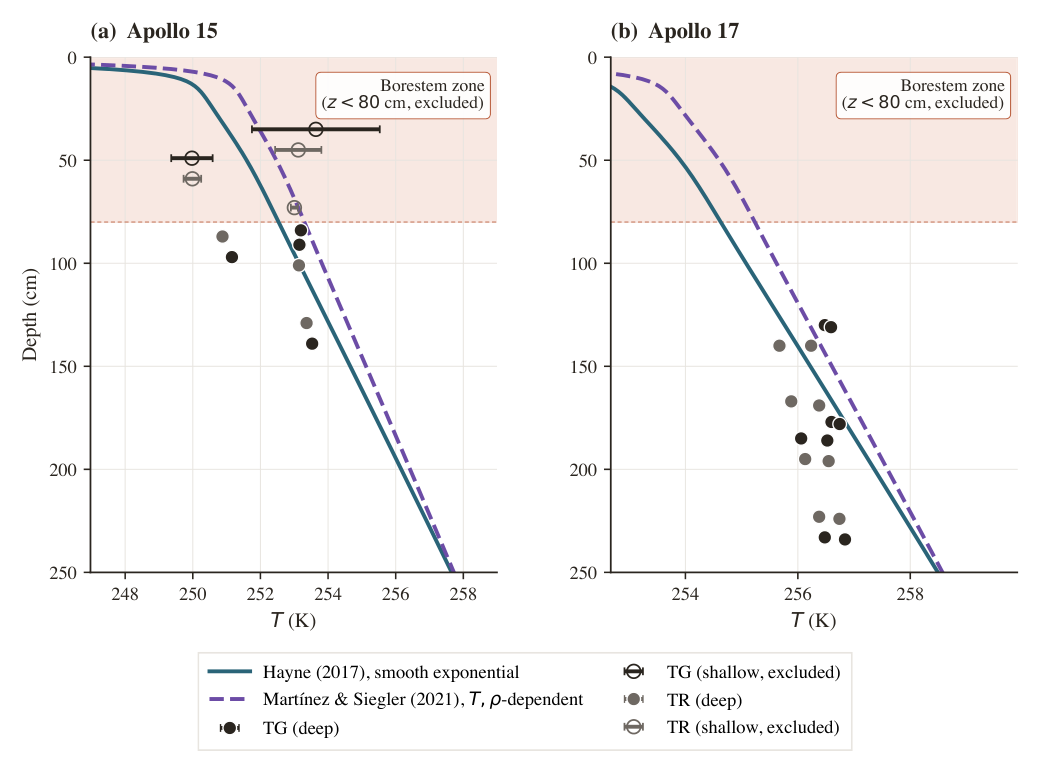

In [2]:
from make_letter_figures import fig_mean_T_profile
fig_mean_T_profile()
show_fig('fig_apollo_mean_T_profile')

## Fig 6 — Per-site K_d sweep (the retrieval itself, visualised)

The deep-sensor RMSE as a function of the trial K_d, one curve per site,
with the fitted minimum K_d\* marked and the bootstrap 95% CI shaded. This
is literally the curve `retrieve_kd.py` minimises.

**What to look for:** each curve has a single clear minimum (a
well-posed fit), and **A17's minimum sits at a noticeably higher K_d than
A15's**. That horizontal gap between the two minima *is* the inter-site
conductivity contrast.

Lunar-V2 notebook bootstrap
  python : /Users/rp3gregorio/Developer/Lunar-Clean/.venv/bin/python
  repo   : /Users/rp3gregorio/Developer/Lunar-Clean/code
  deps   : all present
  lunar  : /Users/rp3gregorio/Developer/Lunar-Clean/code/src/lunar/__init__.py
Ensuring Apollo HFE (a15) ...


Ensuring Apollo HFE (a17) ...


  → /Users/rp3gregorio/Developer/Lunar-Clean/code/../figures/fig_kd_sweep.pdf


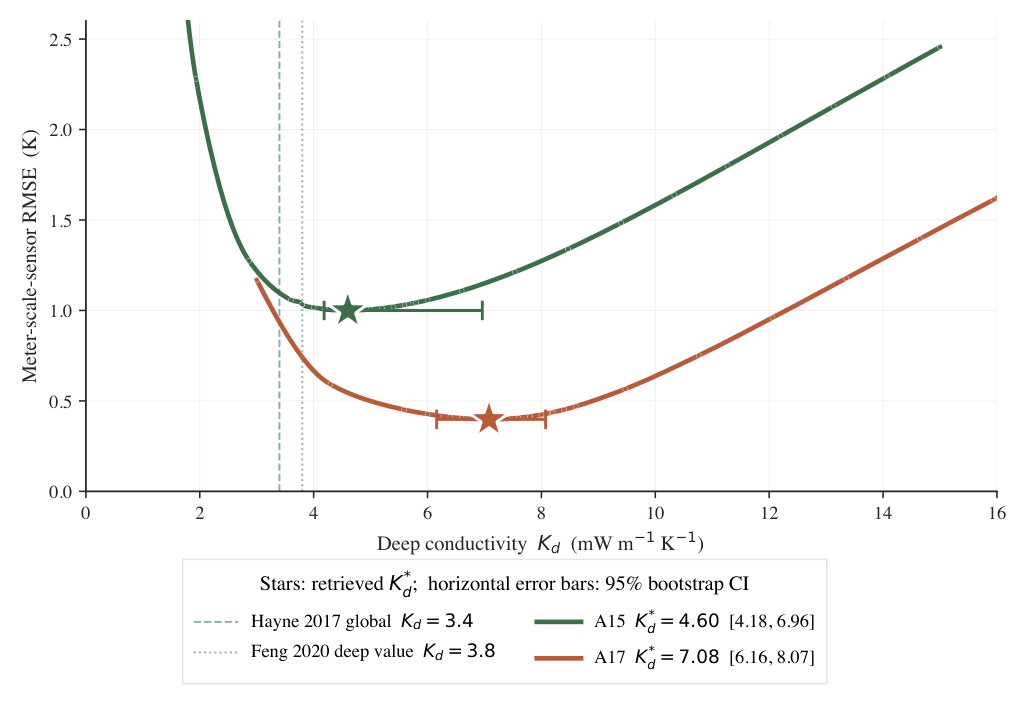

In [3]:
from make_letter_figures import fig_kd_sweep
fig_kd_sweep()
show_fig('fig_kd_sweep')

## Fig 7 — Bootstrap distributions

Histograms of K_d\* from the 1500 bootstrap resamples, one per site. The
spread of each histogram is where the confidence interval comes from; the
"bootstrap" simply re-fits the data many times under small perturbations
to see how stable K_d\* is.

**What to look for:** two well-separated humps — A17's distribution sits
clearly to the right of A15's, with little overlap. That near-non-overlap
is what gives the contrast its p ≈ 0.011.

  → /Users/rp3gregorio/Developer/Lunar-Clean/figures/fig_bootstrap.pdf


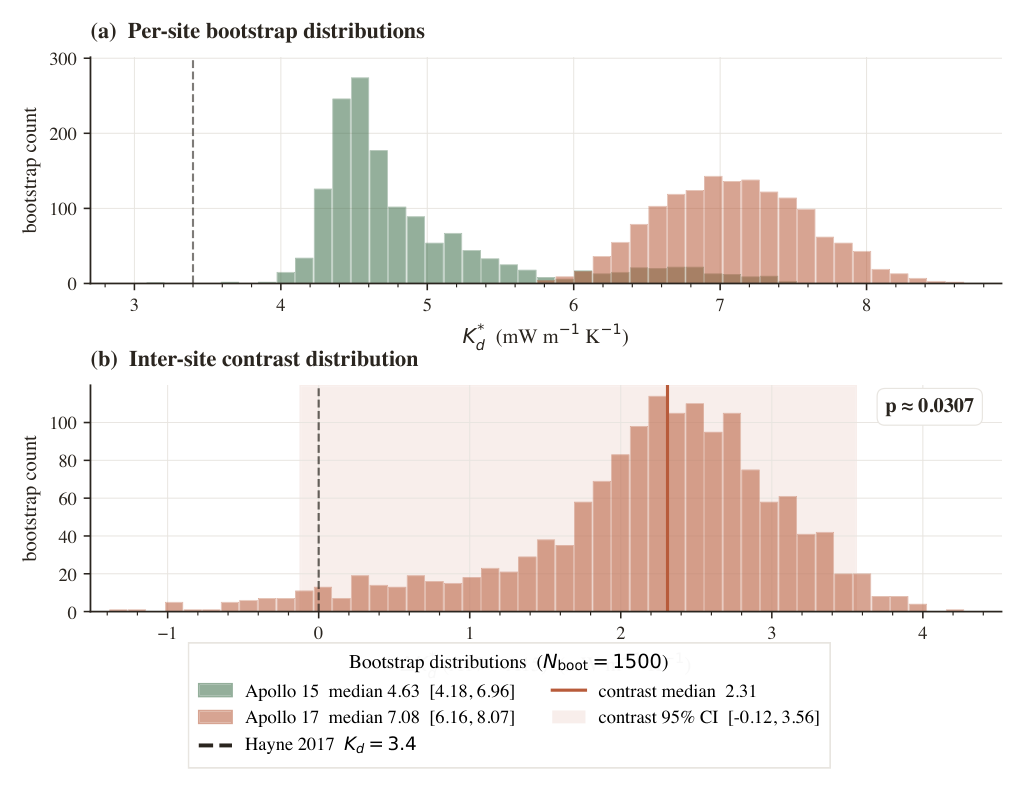

In [4]:
from make_results_figures import fig_bootstrap
fig_bootstrap(d, FIGS / 'fig_bootstrap.pdf')
show_fig('fig_bootstrap')

## Fig 8 — Annual-mean T(z) with the per-site retrieved K_d*

The same depth–temperature profile as Fig 5, but now using each site's
**retrieved** K_d\* instead of the global value, overlaid on the actual
deep-sensor measurements.

**What to look for:** the retrieved-K_d curve should thread through the
data points better than the global-K_d baseline — visual confirmation
that the per-site fit improves the match.

  Running Hayne K_d*=4.60  for A15 ...

  Running M&S model for A15 ...


  Running Hayne K_d*=7.08  for A17 ...


  Running M&S model for A17 ...


  → /Users/rp3gregorio/Developer/Lunar-Clean/figures/fig_thermal_profiles.pdf


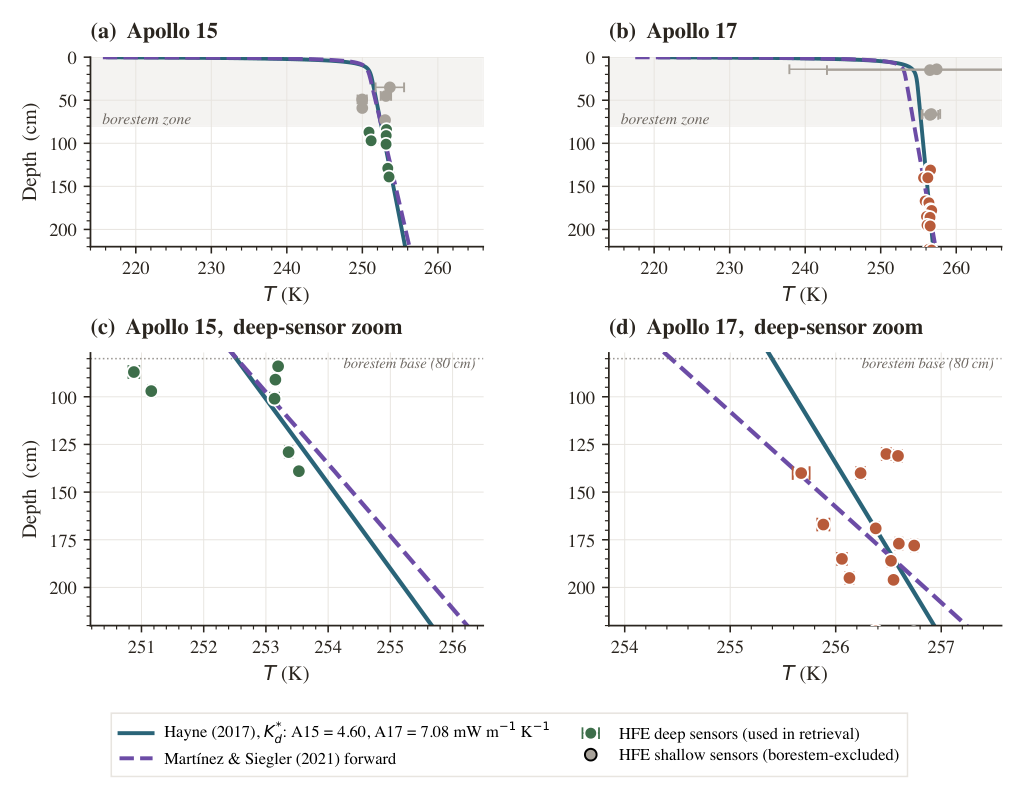

In [5]:
from make_results_figures import fig_thermal_profiles
fig_thermal_profiles(d, FIGS / 'fig_thermal_profiles.pdf')
show_fig('fig_thermal_profiles')

## Fig 9 — Diviner surface-temperature closure (independent check)

An *independent* sanity check that does **not** use the HFE data. We run
the 1-D model forward with the retrieved K_d and compare its predicted
**surface** day–night temperature curve to the Diviner orbital
composite. If the model fit to deep sensors also reproduces the surface
swing measured from orbit, the physics is self-consistent.

Needs the Diviner tiles (`python pipeline/fetch_diviner.py`) and the
retrieval JSON. **What to look for:** the modelled curve tracking the
Diviner points across a full lunar day.

In [6]:
# Fig 9 -- Diviner surface-T closure (reproducible script).
# Requires the GCP tiles: python pipeline/fetch_diviner.py  (~310 MB)
# Reads results/kd_retrieval_results.json (run 02_retrieval first).
# Writes results/diviner_closure.json and
# results/figures/fig_diviner_closure.pdf.
import subprocess, sys
subprocess.run([sys.executable, str(ROOT / 'pipeline' / 'compute' /
                'compute_diviner_closure.py')], check=True)


Lunar-V2 notebook bootstrap
  python : /Users/rp3gregorio/Developer/Lunar-Clean/.venv/bin/python
  repo   : /Users/rp3gregorio/Developer/Lunar-Clean/code
  deps   : all present
  lunar  : /Users/rp3gregorio/Developer/Lunar-Clean/code/src/lunar/__init__.py
Ensuring Apollo HFE (a15) ...
Ensuring Apollo HFE (a17) ...
=== A15 (lat +26.13, K_d* = 4.60 mW/m/K) ===


  Hayne site-fit : RMSE =   4.13 K, bias =  +2.64 K
  Martinez fwd   : RMSE =   3.58 K, bias =  +0.08 K
=== A17 (lat +20.19, K_d* = 7.08 mW/m/K) ===


  Hayne site-fit : RMSE =   6.30 K, bias =  +4.10 K
  Martinez fwd   : RMSE =   3.62 K, bias =  -0.78 K
wrote /Users/rp3gregorio/Developer/Lunar-Clean/code/results/diviner_closure.json


wrote /Users/rp3gregorio/Developer/Lunar-Clean/code/../figures/fig_diviner_closure.pdf


CompletedProcess(args=['/Users/rp3gregorio/Developer/Lunar-Clean/.venv/bin/python', '/Users/rp3gregorio/Developer/Lunar-Clean/code/pipeline/compute/compute_diviner_closure.py'], returncode=0)

## Table 2 — Headline RMSE comparison

The numbers behind the claim "per-site K_d fits better." For each site it
compares the deep-sensor RMSE under three models: the published global
Hayne K_d, the per-site fitted K_d\*, and the Martínez forward model.

**What to look for:** the `K_d* site fit` RMSE is the lowest — and at
Apollo 17 the global model's RMSE is roughly halved by fitting K_d.

In [7]:
import pandas as pd
t2 = json.loads((OUTPUT / 'headline_rmse.json').read_text())
rows = []
for site, sd in t2['sites'].items():
    n = sd['N_deep']
    rows.append((f'Apollo {site[-2:]}', 'Hayne (2017) global K_d',
                 f"{sd['hayne_global']['kd_mW']:.2f}", n,
                 f"{sd['hayne_global']['rmse_K']:.2f}"))
    rows.append((f'Apollo {site[-2:]}', 'Hayne, K_d* site fit',
                 f"{sd['hayne_site_fit']['kd_mW']:.2f}", n,
                 f"{sd['hayne_site_fit']['rmse_K']:.2f}"))
    rows.append((f'Apollo {site[-2:]}', 'Martinez (2021) forward',
                 '--', n,
                 f"{sd['martinez_forward']['rmse_K']:.2f}"))
pd.DataFrame(rows, columns=['Site','Model','K_d (mW/m/K)','N','RMSE (K)'])

,Site,Model,K_d (mW/m/K),N,RMSE (K)
0,Apollo 15,Hayne (2017) global K_d,3.40,7,1.09
1,Apollo 15,"Hayne, K_d* site fit",4.60,7,1.00
2,Apollo 15,Martinez (2021) forward,--,7,1.05
3,Apollo 17,Hayne (2017) global K_d,3.40,16,0.89
4,Apollo 17,"Hayne, K_d* site fit",7.08,16,0.40
5,Apollo 17,Martinez (2021) forward,--,16,0.63


## Table 3 — Per-component error budget

Breaks the total uncertainty on K_d\* into contributions from each source
(statistical bootstrap scatter, sensor-depth uncertainty, albedo,
borestem cut, stability threshold, …), added in quadrature. Shows which
assumptions actually matter for the final error bar.

In [8]:
t3 = json.loads((OUTPUT / 'kd_error_budget.json').read_text())
# kd_error_budget shape: {'A15': {'sigma_stat':..., ...}, 'A17': {...}, ...}
rows = []
for site, sd in t3.items():
    if not isinstance(sd, dict): continue
    if any(k.startswith('sigma') for k in sd.keys()):
        row = {'Site': site}
        for k, v in sd.items():
            if isinstance(v, (int, float)):
                row[k] = f'{v:.2f}' if abs(v) > 0.05 else '<0.05'
        rows.append(row)
pd.DataFrame(rows) if rows else t3

,Site,sigma_stat,sigma_solver,sigma_Qb,sigma_zb,sigma_thr,sigma_A,sigma_Ks,sigma_rho,conditional_chi,conditional_H,kd_at_chi_1p48,total_quadrature,median,ci95_lo,ci95_hi
0,A15,0.53,<0.05,1.61,0.12,<0.05,0.72,0.36,<0.05,3.60,0.51,1.00,1.88,4.63,4.18,6.96
1,A17,0.52,<0.05,1.66,<0.05,<0.05,2.96,1.55,0.33,17.92,3.47,25.00,3.78,7.08,6.16,8.07
